# Leyenda - Livrable 2

## Import des bibliothèques

In [18]:
from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import show_clean_and_noisy_images

import os
import tensorflow as tf
import sys

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)
    
data_loader = DataLoader()
autoencoder_base_loader = ModelLoader(model_name="autoencoder_base")
autoencoder_skiplayer_loader = ModelLoader(model_name="autoencoder_skiplayer")

## Génération des datasets des photos

In [19]:
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="Photo")

Photo Dataset size: 9993


## Bruitage des datasets

Nous commençons par charger nos datasets d’images en RGB. Afin de simuler des conditions réelles où les images peuvent être de mauvaise qualité (photos floues, pixels manquants, artefacts de compression...), nous allons volontairement ajouter du bruit à ces images.

Le bruit correspond ici à une dégradation volontaire des données visuelles. Cela peut se traduire par des perturbations aléatoires dans les pixels, des zones effacées, ou encore un floutage partiel. L’objectif est de simuler un dataset réaliste, tel qu’on pourrait le retrouver dans un contexte réel avec certaine images degradées (ex. caméras de mauvaise qualité, images endommagées...).

Nous allons bruiter 40% des images données avec facteur de bruitage compris entre 0.1 et 0.6, c'est-à-dire que chaque pixels de l’image a 40% de chance d'être bruité par du bruit aléatoire. Le bruit est appliqué de manière aléatoire sur les images, ce qui permet de créer un dataset varié et réaliste. Ce processus est essentiel pour entraîner notre modèle à reconnaître et à corriger les défauts d’images dans des conditions réelles.

In [20]:
noisy_train_list = list(data_loader.add_noise_to_dataset(
    dataset=train_ds,
    noise_factor_range=(0.1, 0.6),
    pixel_noise_prob=0.4))

noisy_val_list = list(data_loader.add_noise_to_dataset(
    dataset=val_ds,
    noise_factor_range=(0.1, 0.6),
    pixel_noise_prob=0.4))

noisy_test_list = list(data_loader.add_noise_to_dataset(
    dataset=test_ds,
    noise_factor_range=(0.1, 0.6),
    pixel_noise_prob=0.4))

# Génération des datasets uniques
noisy_train_list = list(noisy_train_list)
noisy_val_list = list(noisy_val_list)
noisy_test_list = list(noisy_test_list)

In [21]:
# Aplatissage de la liste de batchs en liste d’images individuelles
flattened_noisy_list_train = []
for batch in noisy_train_list:
    for x, y in zip(*batch):
        flattened_noisy_list_train.append((x, y))

flattened_noisy_list_val = []
for batch in noisy_val_list:
    for x, y in zip(*batch):
        flattened_noisy_list_val.append((x, y))

flattened_noisy_list_test = []
for batch in noisy_test_list:
    for x, y in zip(*batch):
        flattened_noisy_list_val.append((x, y))
        
        
noisy_train_ds = tf.data.Dataset.from_generator(
    lambda: iter(flattened_noisy_list_train),
    output_signature=(
        tf.TensorSpec(shape=(256, 256, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)  # ou tf.string selon ton label
    )
).batch(32).cache()

noisy_val_ds = tf.data.Dataset.from_generator(
    lambda: iter(flattened_noisy_list_val),
    output_signature=(
        tf.TensorSpec(shape=(256, 256, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)  # ou tf.string selon ton label
    )
).batch(32).cache()

noisy_test_ds = tf.data.Dataset.from_generator(
    lambda: iter(flattened_noisy_list_test),
    output_signature=(
        tf.TensorSpec(shape=(256, 256, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)  # ou tf.string selon ton label
    )
).batch(32).cache()

Vous pouvez voir ci-dessous le résultat du bruitage appliqué aux images d'entraînement.
C’est à partir de ce dataset bruité que nous allons entraîner notre modèle afin qu’il soit capable de reconstruire une image la plus fidèle possible à l’originale.

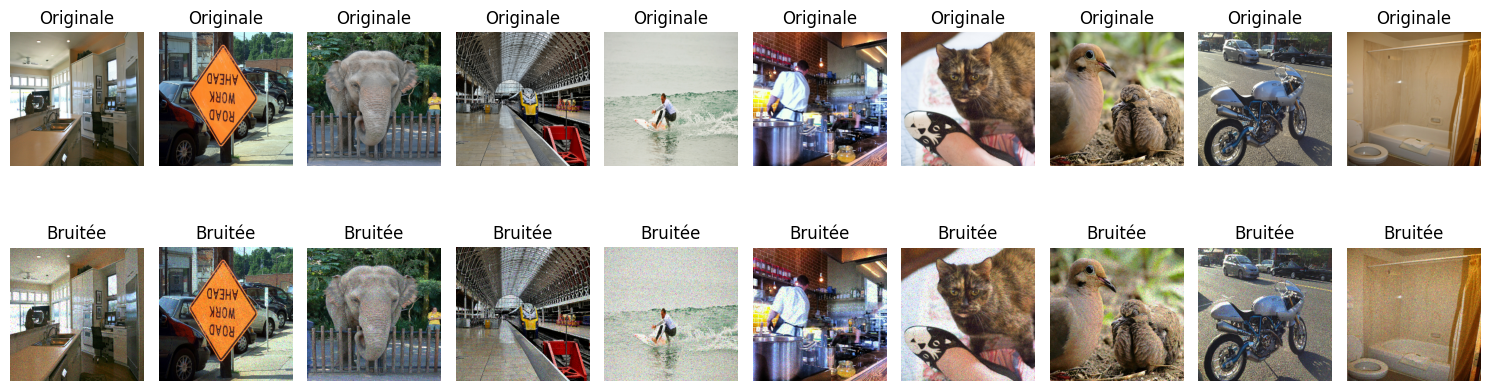

In [22]:
show_clean_and_noisy_images(train_ds, noisy_train_ds, max_images=10, batch_index=10)

Maintenant, nous créons la paire d’images bruitées et originales pour l’entraînement du modèle grâce à la fonction ```make_autoencoder_dataset``` de la classe ModelLoader. Cette fonction prend en entrée le dataset bruité et le dataset original, et génère un dataset d’autoencodeur contenant les images bruitées et leurs correspondances originales.

In [23]:
train_autoenc_ds = autoencoder_base_loader.make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = autoencoder_base_loader.make_autoencoder_dataset(noisy_val_ds, val_ds)

## Débruitage avec un Autoencodeur Convolutif

Pour effectuer le débruitage des images, nous utilisons deux autoencodeurs convolutifs, un type de réseau de neurones spécialement conçu pour apprendre à compresser puis reconstruire des images.

Le principe de l’autoencodeur repose sur deux parties principales :

L'encodeur prend en entrée une image bruitée (256x256x3) et applique une série de convolutions, de normalisations et de MaxPooling afin de réduire progressivement la taille de l’image tout en capturant ses caractéristiques les plus importantes.
À la fin de l’encodeur, l’image est aplatie puis projetée dans un espace latent (vecteur de 256 dimensions), qui contient une version compressée et encodée de l’information.

Le décodeur prend ce vecteur latent et tente de reconstruire l’image d’origine en effectuant l’opération inverse.
Il commence par redimensionner le vecteur latent en une forme compatible avec des convolutions.
Ensuite, grâce à des couches de convolutions transposées, il reconstruit petit à petit une image de même taille que celle d’entrée.
La sortie finale est une image "nettoyée", censée être la version débruitée de l’entrée.


La particularité de l'autoencodeur avec skiplayer est que nous avons ajouté des connexions de saut (skip connections) entre certaines couches de l'encodeur et du décodeur. Ces connexions permettent de transmettre directement certaines caractéristiques de l'image d'entrée à la sortie, ce qui peut aider à préserver des détails importants lors de la reconstruction. En d'autres termes, elles facilitent le passage d'informations pertinentes à travers le réseau, améliorant ainsi la qualité de la sortie finale.

### Création des autoencodeurs
Nous avons décidé de créer 2 autoencodeurs, l'un de base et l'autre avec des skip layers.

In [24]:
autoencoder_base = autoencoder_base_loader.create_base_autoencoder(show_summary=False)
autoencoder_skiplayer = autoencoder_skiplayer_loader.create_skip_layer_autoencoder(show_summary=False)

Encoder created successfully.
Decoder created successfully.
Autoencoder autoencoder_base created successfully.
Encoder created successfully.
Decoder created successfully.
Autoencoder autoencoder_skiplayer created successfully.


### Entraînement des modèles

Nous entraînons ces modèles, l'idée est de permettre au modèle d'apprendre à partir d'exemples comment corriger automatiquement les défauts présents dans des images de mauvaise qualité. Pour ce faire, nous utilisons des paires d'images comme vu précedemment (une version bruitée, volontairement altérée, et sa version originale non bruitée). Le rôle du modèle est d'apprendre à reconstruire l’image originale à partir de sa version bruitée.

L'entraînement consiste à montrer au modèle un grand nombre de ces paires. À chaque itération, le modèle produit une image de sortie qu’il tente de rendre la plus proche possible de l’image originale. Cet écart est mesuré à l’aide d’une fonction de perte, ici la binary crossentropy, qui évalue la différence entre l’image générée et l’image de référence. Le modèle ajuste alors ses paramètres internes afin de minimiser cette erreur. Répété sur plusieurs cycles d’apprentissage, ce processus permet au modèle d’améliorer progressivement sa capacité à supprimer le bruit et à restituer les détails essentiels.

Nous avons évalué nos modèles en les entraînant avec une fonction de perte différentes : MAE. La loss oriente l’apprentissage selon une logique propre : MAE minimise les erreurs numériques.

Lors de l’entraînement, les modèles ajustent leurs paramètres dans le but de minimiser cette fonction de perte. Autrement dit, ils apprennent à produire des résultats qui améliorent progressivement la métrique définie par la loss choisie. Par exemple, si la loss est MAE, le modèle va chercher à réduire l’erreur absolue entre ses prédictions et les valeurs réelles. Cela signifie qu’il va s’efforcer de produire des sorties qui se rapprochent le plus possible des cibles, en minimisant les écarts entre les deux.

In [25]:
with tf.device("/gpu:0"):
    base_autoencoder_history = autoencoder_base.fit(
                    train_autoenc_ds,
                    epochs=1,
                    batch_size= 32,
                    validation_data=val_autoenc_ds,
                    verbose=2,
                    callbacks=[autoencoder_base_loader.get_early_stopping(), autoencoder_base_loader.get_model_checkpoint()]   
                   )
    
    skiplayer_autoencoder_history = autoencoder_skiplayer.fit(
                    train_autoenc_ds,
                    epochs=1,
                    batch_size= 32,
                    validation_data=val_autoenc_ds,
                    verbose=2,
                    callbacks=[autoencoder_skiplayer_loader.get_early_stopping(), autoencoder_skiplayer_loader.get_model_checkpoint()]
                   )

C:\Users\mattk\OneDrive\Documents\Git projects\Leyendo\.venv\lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


199/199 - 373s - 2s/step - loss: 0.0976 - mae: 0.0971 - psnr_metric: 17.8064 - ssim_metric: 0.3972 - val_loss: 0.1269 - val_mae: 0.1249 - val_psnr_metric: 16.0063 - val_ssim_metric: 0.3919


AttributeError: 'tuple' object has no attribute 'fit'

## Évaluation des performances

Dans cette section, nous affichons les résultats en comparant visuellement trois versions d’une même image : l’image originale, sa version bruitée, puis l’image reconstruite par le modèle. Cette comparaison visuelle permet d’apprécier à l’œil nu l’efficacité du modèle de débruitage. Plus l’image reconstruite se rapproche de l’originale, plus la qualité de la restauration semble satisfaisante.

Toutefois, pour évaluer de manière plus rigoureuse et précise la performance du modèle, nous utilisons plusieurs métriques quantitatives telles que le PSNR, le SSIM, le MAE, le Laplacien et le Tenegrad. Croiser ces métriques avec différentes fonctions de perte permet de comparer objectivement les résultats selon plusieurs critères de qualité. Cela nous aide à identifier quelle combinaison de loss et de métriques produit l'entraînement le plus pertinent et le plus adapté à nos objectifs.

### Modèle de base

<img src="./../figures/Compare_base_autoencoder_images.png" alt="Image de comparaison du modèle base" style="width: 100%; height: auto;"/>

#### Courbes d'évolution des métriques durant l'entraînement

<img src="./../figures/Val_loss_base_autoencoder.png" alt="Image de la courbe de validation du modèle base" style="width: 100%; height: auto;"/>

<img src="./../figures/MAE_base_autoencoder.png" alt="Image de la courbe MAE du modèle base" style="width: 100%; height: auto;"/>

<img src="./../figures/SSIM_base_autoencoder.png" alt="Image de la courbe SSIM du modèle base" style="width: 100%; height: auto;"/>

<img src="./../figures/PSNR_base_autoencoder.png" alt="Image de la courbe PSNR du modèle base" style="width: 100%; height: auto;"/>

### Modèle Skiplayer

<img src="./../figures/Compare_skiplayer_autoencoder_images.png" alt="Image de comparaison du modèle skiplayer" style="width: 100%; height: auto;"/>

#### Courbes d'évolution des métriques durant l'entraînement


<img src="./../figures/Val_loss_skiplayer_autoencoder.png" alt="Image de la courbe de validation du modèle skiplayer" style="width: 100%; height: auto;"/>

<img src="./../figures/MAE_skiplayer_autoencoder.png" alt="Image de la courbe MAE du modèle skiplayer" style="width: 100%; height: auto;"/>

<img src="./../figures/SSIM_skiplayer_autoencoder.png" alt="Image de la courbe SSIM du modèle skiplayer" style="width: 100%; height: auto;"/>

<img src="./../figures/PSNR_skiplayer_autoencoder.png" alt="Image de la courbe PSNR du modèle skiplayer" style="width: 100%; height: auto;"/>

### Explication des différentes métriques de comparaison

**Netteté (Laplacian):**
Évalue la netteté d'une image à l'aide du filtre Laplacien, basé sur l’analyse des contours. La valeur est relative et dépend des images. Une valeur élevée indique une image plus nette, tandis qu’une valeur faible indique une image floue.

**Tenegrad:**
Autre indicateur de netteté, fondé sur le calcul des gradients à l’aide de l’opérateur de Sobel. Comme pour le Laplacien, plus la valeur est élevée, plus l’image est considérée comme nette. Cet indicateur est généralement moins sensible au bruit.

**MAE (Mean Absolute Error):**
Mesure la moyenne des erreurs absolues entre les prédictions et les valeurs réelles. Typiquement exprimée entre 0 et 1. Une valeur plus faible indique de meilleures performances, car les prédictions sont plus proches des valeurs attendues.

**SSIM (Structural Similarity Index):**
Mesure la similarité structurelle entre deux images. Sa valeur varie entre 0 et 1, où 1 signifie que les deux images sont identiques. Une valeur élevée est synonyme de bonne qualité de reconstruction, en tenant compte de la luminance, du contraste et de la structure.

**PSNR (Peak Signal-to-Noise Ratio):**
Évalue la qualité d’une image reconstruite en comparant le rapport entre le signal maximal et le bruit. Exprimée en décibels (dB), elle varie généralement entre 20 et 40 dB. Une valeur élevée indique une image de meilleure qualité. Une PSNR supérieure à 30 dB est considérée comme correcte, et supérieure à 40 dB comme excellente.

### Tableau des métriques

| Modèle                      | Netteté (Laplacian) | Tenegrad | MAE    | SSIM  | PSNR (dB) |
|-----------------------------|---------------------|----------|--------|-------|-----------|
| Modèle base + loss MAE      | 7.78%               | 72.33%   | 0.050  | 0.629 | 22.9      |
| Modèle skiplayer + loss MAE | 131.57%             | 106.29%  | 0.0426 | 0.684 | 24.7      |

### Analyse des résultats
Une fois les deux modèles entraînés, nous avons comparé leurs performances respectives. Le modèle intégrant des skip layers a offert les meilleurs résultats. Grâce à ces connexions directes entre les couches d'encodage et de décodage, le réseau parvient à mieux conserver les détails fins de l’image d’origine. Les contours sont plus nets, les couleurs plus fidèles, et le bruit est efficacement atténué. Ces observations montrent que le modèle avec skip layers exploite plus efficacement l'information visuelle pertinente.

À l’inverse, le modèle classique, sans skip layers, génère des images de qualité inférieure : les détails sont plus flous, certaines zones manquent de précision, et l'atténuation du bruit est moins marquée. Cela laisse penser que l’absence de connexions de type skip limite la capacité du réseau à restituer les informations fines perdues lors de l'encodage.

Nous avons donc choisi de retenir le modèle avec skip layers pour la suite du projet. Certaines limites persistent, notamment pour les images les plus fortement bruitées, où la restitution pourrait encore être optimisée. Pour améliorer les performances, il serait pertinent d’envisager un entraînement plus long, une plus grande diversité de données ou encore une optimisation plus poussée de l’architecture. À noter que les deux modèles partagent la même fonction de perte, ce qui garantit une comparaison équitable. Le modèle retenu constitue une base solide pour des applications plus complexes en vision par ordinateur.


## Conclusion

Ce travail de débruitage a pour but d’améliorer légèrement la qualité des images avant de les utiliser dans d’autres tâches comme la classification ou le captioning. Étant donné que les datasets utilisés dans le projet sont de bonnes qualités, il est peu probable que l’on rencontre des niveaux de dégradation aussi élevés que ceux utilisés pendant l'entraînement. Cela signifie que le modèle que nous avons obtenu, bien qu'entraîné sur des images très bruitées, sera largement suffisant pour traiter de légers défauts comme une image floue ou légèrement altérée. Il pourra ainsi contribuer à améliorer les performances des modèles de captioning, en leur fournissant une image un peu plus claire à interpréter.